# Notebook to replicate supplemental control figures for visual behavior paper

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

import seaborn as sns
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 1})

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
import visual_behavior.visualization.utils as utils
import visual_behavior.data_access.loading as loading
import visual_behavior.data_access.utilities as utilities

from visual_behavior.dimensionality_reduction.clustering import plotting # functions to plot clusters
from visual_behavior.dimensionality_reduction.clustering import processing # function for computing and validating clusters

import visual_behavior.visualization.ophys.platform_paper_figures as ppf

c:\Users\marinag\Anaconda3\envs\visual_behavior_sdk_new\lib\site-packages\statsmodels\compat\pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex
c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentat

In [4]:
import visual_behavior_glm.GLM_fit_dev as gfd
import visual_behavior_glm.GLM_analysis_tools as gat
import visual_behavior_glm.GLM_across_session as gas

In [5]:
run_examples=False # skip example runs to run the notebook faster

# Cell ID shuffle control

## Supplemental figure 20

#### Load original data

In [6]:
experience_level_colors = utils.get_experience_level_colors()
cre_line_colors = utils.get_cre_line_colors()

experience_levels = utils.get_new_experience_levels()
cell_types = utils.get_cell_types()

In [7]:
# path to data files
base_path = '//allen/programs/braintv/workgroups/nc-ophys/visual_behavior/platform_paper_cache_new'
save_dir = os.path.join(base_path, 'clustering')

# folder containing saved shuffle files
data_folder = 'shuffled_files'

# create folder to save results and figures to to
folder = 'shuffle_control'

# figures go into a different directory
fig_path = '//allen/programs/braintv/workgroups/nc-ophys/visual_behavior/platform_paper_figures_final/figure_4_tmp'

### Load metadata tables & cluster results 

In [8]:
platform_cache_dir = loading.get_platform_analysis_cache_dir()
print(platform_cache_dir)

\\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_cache_new


In [9]:
# metadata tables
experiments_table = pd.read_csv(os.path.join(platform_cache_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(platform_cache_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(platform_cache_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(platform_cache_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# get lists of matched cells and expts
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# get cre_lines and cell types for plot labels
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utils.get_cell_types()



In [10]:


### clustering results ###

# n_clusters that was used
n_clusters = 14

# clustering input
feature_matrix = pd.read_hdf(os.path.join(platform_cache_dir, 'clustering', 'clustering_feature_matrix.h5'), key='df')
feature_matrix = feature_matrix.rename(columns={'all-images':'images', 'behavioral': 'behavior'})

# clustering output
cluster_meta = pd.read_hdf(os.path.join(platform_cache_dir, 'clustering', 'cluster_metadata_'+str(n_clusters)+'_clusters.h5'), key='df')



In [11]:
original_feature_matrix = feature_matrix.copy()
original_cluster_meta = cluster_meta.copy()

#### Load original feature matrix, meta data and cluster labels

In [12]:
# # coding scores from GLM for matched cells during familiar, novel, and novel+ sessions
# filename = 'clustering_feature_matrix.h5'
# original_feature_matrix = pd.read_hdf(os.path.join(save_dir, filename), key='df')
# len(original_feature_matrix)

In [13]:
# # cluster assignments and other info about the cells. Note that 20 cells were dropped post clustering since there were less than 5 of them in a cluster
# filename = 'old_files/cluster_meta_14_clusters.h5' 
# original_cluster_meta = pd.read_hdf(os.path.join(save_dir, filename), key='df')
# len(original_cluster_meta)

In [14]:
# # this should be the way to laod cells table
# filename = 'cell_metadata.h5'
# cells_table = pd.read_hdf(os.path.join(save_dir, filename), key='df')
# matched_cells_table = loading.get_matched_cells_table(cells_table)

In [15]:
# # REMOVE!!!
# # run this cell if cell above doesnt run
# filename = 'old_files/cell_metadata.pkl'
# cells_table = pd.read_pickle(os.path.join(save_dir, filename))


In [16]:
# # run this cell if cell above doesnt run
# filename = 'old_files/matched_cells_table.pkl'
# cells_table = pd.read_pickle(os.path.join(save_dir, filename))

### Compute mean cluster coding scores for the original data

In [17]:
# 12x1 matrix
original_mean_dropout_scores = processing.get_mean_dropout_scores_per_cluster(original_feature_matrix, 
                                                  cluster_meta = original_cluster_meta.reset_index(), sort_by_cluster_size=False)
# dictionary of 4x3 clusters
original_mean_dropout_scores_unstacked = processing.get_mean_dropout_scores_per_cluster(original_feature_matrix, stacked=False, 
                                                  cluster_meta = original_cluster_meta.reset_index(), sort_by_cluster_size=False)

<AxesSubplot:xlabel='None-experience_level'>

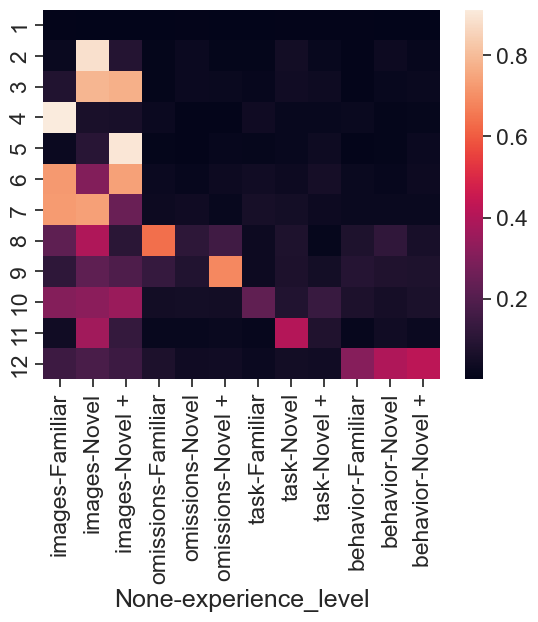

In [18]:
cluster_ids = np.arange(1, 13, 1)
sns.heatmap(original_mean_dropout_scores.T)

In [19]:
# split cell specimen ids by cre lines 
cre_ids = {}
cre_lines = np.sort(original_cluster_meta.cre_line.unique())
for cre_line in cre_lines:
    cre_ids[cre_line]=original_cluster_meta[original_cluster_meta.cre_line==cre_line].index.values
    

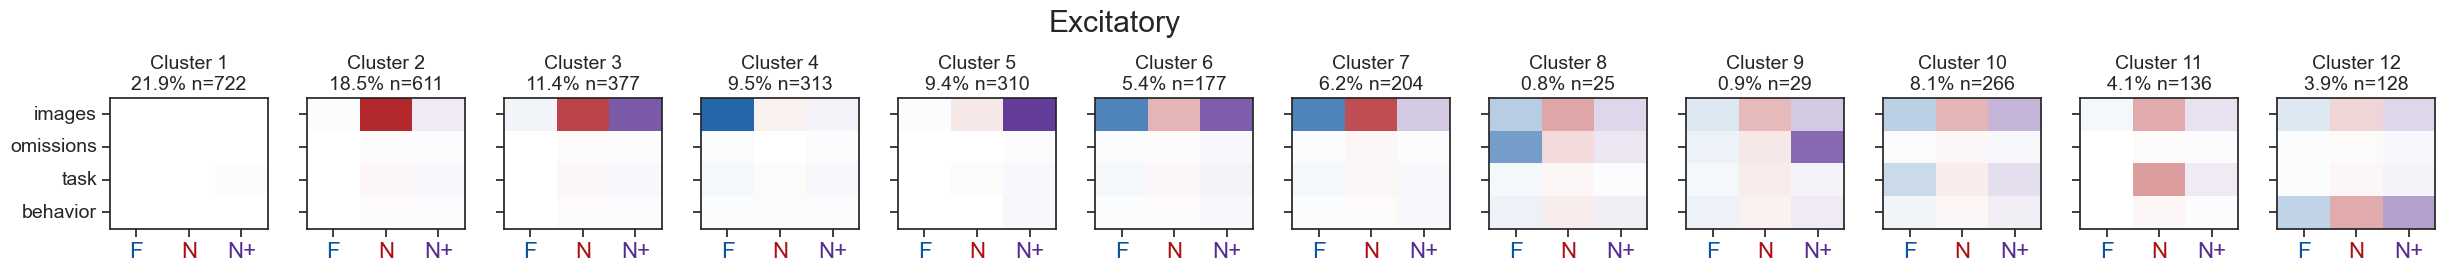

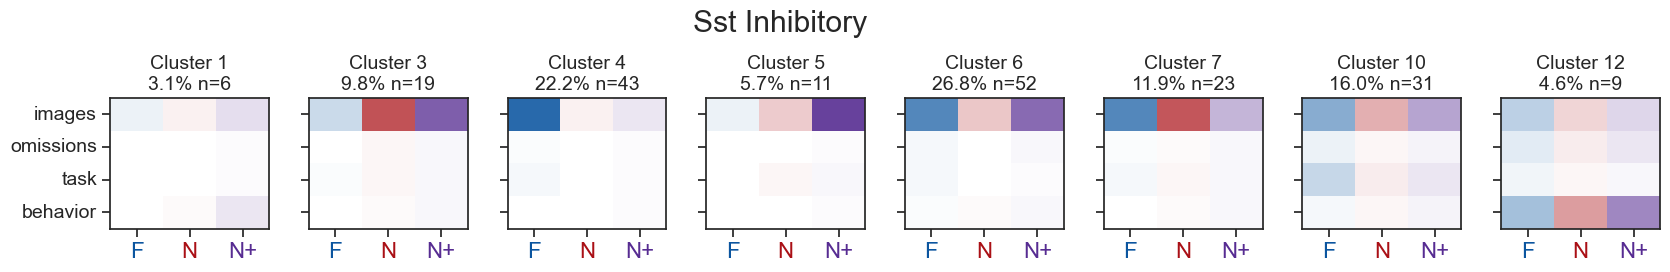

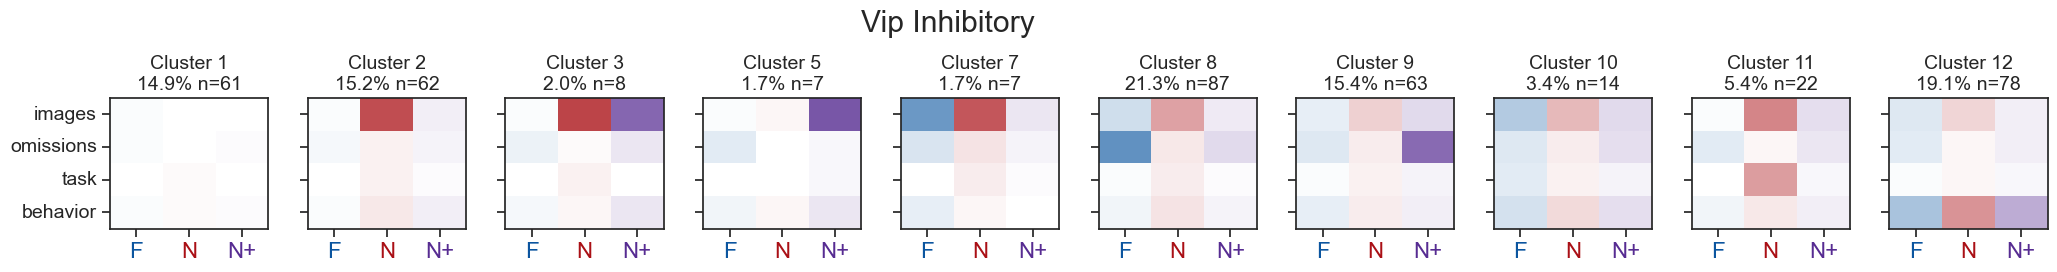

In [20]:
for cre_line in cre_lines:
    cluster_meta_cre = original_cluster_meta[original_cluster_meta.cre_line==cre_line]
    plotting.plot_mean_cluster_heatmaps_remapped(original_feature_matrix, cluster_meta_cre, cre_line=cre_line, 
                                                 annotate=False, session_colors=True, sort_by='cluster_id',
                                                 save_dir=fig_path, folder=folder, suffix='_original_clusters')

#### Load shuffled data 

One file for each n_boot, containing shuffled feature matrix

In [21]:
os.path.join(save_dir, data_folder)

'//allen/programs/braintv/workgroups/nc-ophys/visual_behavior/platform_paper_cache_new\\clustering\\shuffled_files'

In [39]:
# Original data in clusters was shuffled 500 times. 

# Path to cached shuffled coding scores
shuffle_dir = os.path.join(save_dir, data_folder)

n_boots=np.arange(500)
shuffle_type = 'experience'

In [23]:
%%time
filepath = os.path.join(save_dir, folder, 'shuffled_feature_matrices.pkl')
if os.path.exists(filepath):
    print('loading shuffled matrices')
    with open(filepath, 'rb') as f:
        shuffled_feature_matrices = pickle.load(f)
else: 
    ## Load shuffled feature matrices
    shuffle_dir = os.path.join(save_dir, data_folder)
    n_boots=np.arange(500)
    shuffle_type = 'experience'
    shuffled_feature_matrices = {}
    for n_boot in n_boots:
        nb_filename ='all_cells_{}_nb{}.h5'.format(shuffle_type, n_boot)
        feature_matrix = pd.read_hdf(os.path.join(shuffle_dir, nb_filename), key = 'df')
        # clean the names of the experience levels and make sure that regressors are ordered correctly
        feature_matrix = feature_matrix[processing.get_features_for_clustering()].rename(mapper = {'Novel 1': 'Novel', 'Novel >1': 'Novel +'}, axis=1)
        feature_matrix = feature_matrix.rename(columns={'all-images':'images', 'behavioral':'behavior'})
        shuffled_feature_matrices[n_boot] = feature_matrix
    # save it 
    print('saving shuffled matrices')
    filepath = os.path.join(save_dir, folder, 'shuffled_feature_matrices.pkl')
    with open(filepath, 'wb') as f:
        pickle.dump(shuffled_feature_matrices, f)


CPU times: total: 15.6 ms
Wall time: 4.1 s


In [24]:
# filepath = os.path.join(save_dir, folder, 'shuffled_feature_matrices.pkl')
# with open(filepath, 'wb') as f:
#     pickle.dump(shuffled_feature_matrices, f)

In [25]:
# to create new shuffled data:
if run_examples:
    shuffled_matrix_example = processing.shuffle_dropout_score(feature_matrix, shuffle_type='experience', separate_cre_lines=False)

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\plotting.py:1800: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  feature_matrix_cre.append(feature_matrix.loc[cids], ignore_index=True)
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\plotting.py:1800: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  feature_matrix_cre.append(feature_matrix.loc[cids], ignore_index=True)
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\plotting.py:1800: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  feature_matrix_cre.append(feature_matrix.loc[cids], ignore_index=True)
C

array([<AxesSubplot:title={'center':'Excitatory'}, xlabel='experience_level'>,
       <AxesSubplot:title={'center':'Sst Inhibitory'}, xlabel='experience_level'>,
       <AxesSubplot:title={'center':'Vip Inhibitory'}, xlabel='experience_level'>],
      dtype=object)

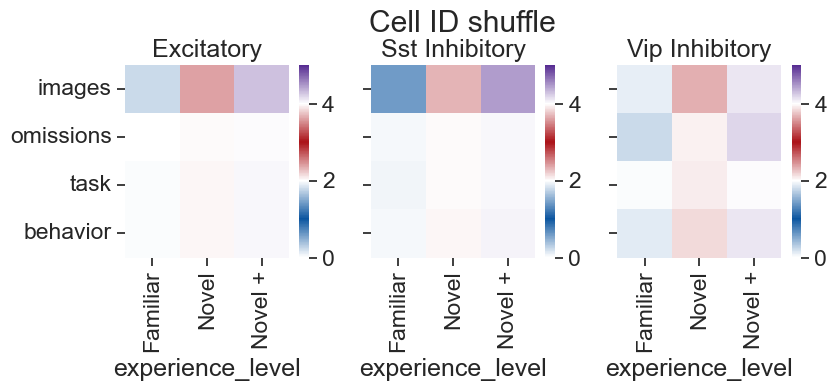

In [26]:
# plot mean dropout scores for shuffled dataset, which should look like the original
plotting.plot_mean_shuffled_feature_matrix(shuffled_feature_matrices, original_cluster_meta, 
                                           session_colors=True, experience_index=None, save_dir=fig_path, folder=folder)


#### Cluster shuffled data

In [27]:
if run_examples:
    # example of clustering one shuffled dataset.
    # to apply it to multiple shuffled dataset, loop through shuffled_feature_matrices
    from sklearn.cluster import SpectralClustering
    n_clusters=12 # same as what we have in original data, this can be optimized for each clustering iteration, but would be very time consuming.
    sc = SpectralClustering()
    X = feature_matrix.values
    m = processing.get_coClust_matrix(X=X, n_clusters=n_clusters, model=sc, nboot=np.arange(150)) #
    # make co-clustering matrix a dataframe with cell_specimen_ids as indices and columns
    coclustering_df = pd.DataFrame(data=m, index=feature_matrix.index, columns=feature_matrix.index)
    shuffled_cluster_meta = processing.create_and_save_cluster_meta(coclustering_df, n_clusters, feature_matrix, matched_cells_table, cluster_meta_filename=None)


#### Load cluster labels

One file per cluster iteration, containing cluster_meta cluster labels, associated with shuffled feature matrices loaded above

In [ ]:
%%time
filepath = os.path.join(save_dir, folder, 'shuffled_labels.pkl')
if os.path.exists(filepath):
    print('loading shuffled labels')
    with open(filepath, 'rb') as f:
        shuffled_labels = pickle.load(f)
else: 
    ## Load shuffled cluster labels
    nb_labels_shuffled = {}                       
    for n_boot in n_boots:
        nb_filename ='all_cells_{}_nb{}_cluster_labels.h5'.format(shuffle_type, n_boot) 
        full_filename = os.path.join(shuffle_dir, nb_filename)
        nb_labels_shuffled[n_boot] = pd.read_hdf(full_filename, key = 'clustered_df')
    shuffled_labels = nb_labels_shuffled
    # save it 
    print('saving shuffled labels')
    filepath = os.path.join(save_dir, folder, 'shuffled_labels.pkl')
    with open(filepath, 'wb') as f:
        pickle.dump(shuffled_labels, f)


loading shuffled labels
CPU times: total: 297 ms
Wall time: 689 ms


In [31]:
# filepath = os.path.join(save_dir, folder, 'shuffled_labels.pkl')
# with open(filepath, 'wb') as f:
#     pickle.dump(shuffled_labels, f)

In [32]:
# this is a dict with keys for n_boots, values are dicts of cluster meta
shuffled_labels[0]

,cell_specimen_id,cre_line,cluster_id,labels
0,1086490067,Slc17a7-IRES2-Cre,3,2
1,1086490073,Slc17a7-IRES2-Cre,7,6
2,1086490095,Slc17a7-IRES2-Cre,4,3
3,1086490129,Slc17a7-IRES2-Cre,8,7
4,1086490246,Slc17a7-IRES2-Cre,11,10
...,...,...,...,...
3896,1086673279,Vip-IRES-Cre,12,11
3897,1086673299,Vip-IRES-Cre,4,3
3898,1086673376,Vip-IRES-Cre,12,11
3899,1086673402,Vip-IRES-Cre,3,2


### Rename clusters in shuffled data

loop through cluster iterations, get shuffled cluster_meta, relabel 

actually we dont need to do this because the cluster IDs in shuffled clusters dont matter - they will be matched to original clusters in a subsequent step

In [33]:
# new_cluster_order = np.asarray(plotting.get_cluster_order())

# shuffled_labels_relabled = {}
# for n_boot in list(shuffled_labels.keys()):
#     shuffled_labels_n_boot = shuffled_labels[n_boot].copy()
#     shuffled_labels_n_boot['original_cluster_id'] = shuffled_labels_n_boot.cluster_id.values
#     shuffled_labels_n_boot['new_cluster_id'] = [np.where(new_cluster_order==cluster_id)[0][0]+1 for cluster_id in shuffled_labels_n_boot.cluster_id.values]
#     shuffled_labels_n_boot['cluster_id'] = shuffled_labels_n_boot['new_cluster_id']
#     shuffled_labels_relabled[n_boot] = shuffled_labels_n_boot

In [34]:
# shuffled_labels_relabled[300][:10]

In [35]:
# shuffled_labels = shuffled_labels_relabled.copy()

In [36]:
# cluster_meta[['original_cluster_id', 'new_cluster_id', 'cluster_id']][:10]

#### Compute mean dropout scores for each cluster, each shuffle type, cre_line, and nboot from shuffled dfs

Mean dropout scores are needed for each cluster in order to match original clusters with shuffled

In [37]:
n_clusters=12

#### dropout scores for shuffled clusters for each clustering iteration 

In [40]:
# mean dropout scores for all 12 clusters in each iteration of shuffle for all cell types together
# these averages are what is used to compare shuffled clusters to original clusters when computing SSE

# get shuffled cluster dropout scores as an array of features x exp (rows) by cluster IDs (cols) for each n_boot
nb_mean_dropout_scores_shuffled = {}
for n, n_boot in enumerate(n_boots):
    cluster_meta = shuffled_labels[n] # cluster ids with cell specimen ids
    feature_matrix = shuffled_feature_matrices[n] # shuffled feature matrix
    mean_dropout_scores = processing.get_mean_dropout_scores_per_cluster(feature_matrix, 
                                                      cluster_meta=cluster_meta, stacked=True, max_n_clusters=n_clusters)
    nb_mean_dropout_scores_shuffled[n] = mean_dropout_scores


In [41]:
%%time
filepath = os.path.join(save_dir, folder, 'mean_dropout_scores_shuffled.pkl')
if os.path.exists(filepath):
    with open(filepath, 'rb') as f:
        nb_mean_dropout_scores_shuffled = pickle.load(f)
else: 
    # get shuffled cluster dropout scores as an array of features x exp (rows) by cluster IDs (cols) for each n_boot
    nb_mean_dropout_scores_shuffled = {}
    for n, n_boot in enumerate(n_boots):
        cluster_meta = shuffled_labels[n] # cluster ids with cell specimen ids
        feature_matrix = shuffled_feature_matrices[n] # shuffled feature matrix
        mean_dropout_scores = processing.get_mean_dropout_scores_per_cluster(feature_matrix, 
                                                        cluster_meta=cluster_meta, stacked=True, max_n_clusters=n_clusters)
        nb_mean_dropout_scores_shuffled[n] = mean_dropout_scores
    # save it 
    filepath = os.path.join(save_dir, folder, 'mean_dropout_scores_shuffled.pkl')
    with open(filepath, 'wb') as f:
        pickle.dump(nb_mean_dropout_scores_shuffled, f)


CPU times: total: 15.6 ms
Wall time: 373 ms


In [42]:
n_boot = 0
nb_mean_dropout_scores_shuffled[n_boot]

1         2         3         4         5   \
          experience_level                                                     
images    Familiar          0.047641  0.846263  0.184160  0.065043  0.147250   
          Novel             0.815227  0.835301  0.335246  0.091635  0.215564   
          Novel +           0.077830  0.091448  0.209680  0.092465  0.238819   
omissions Familiar          0.010151  0.024982  0.104973  0.012168  0.044907   
          Novel             0.038098  0.035501  0.036411  0.018334  0.054485   
          Novel +           0.014015  0.011901  0.375021  0.013229  0.053549   
task      Familiar          0.026183  0.053884  0.035735  0.033491  0.024385   
          Novel             0.065079  0.070352  0.077903  0.040527  0.060622   
          Novel +           0.034908  0.036204  0.042683  0.030921  0.030295   
behavior  Familiar          0.012314  0.028851  0.357986  0.015296  0.052727   
          Novel             0.027862  0.024628  0.068034  0.019598  0.599066   
          Novel +           0.014127  0.030303  0.067104  0.020629  0.058075   

                                  6         7         8         9         10  \
          experience_level                                                     
images    Familiar          0.065556  0.855016  0.070660  0.000000  0.138516   
          Novel             0.829906  0.421525  0.068279  0.000000  0.438673   
          Novel +           0.817007  0.850813  0.816471  0.482521  0.199154   
omissions Familiar          0.015629  0.041568  0.013436  0.000000  0.033417   
          Novel             0.027707  0.024882  0.014863  0.000000  0.024313   
          Novel +           0.026945  0.024058  0.024973  0.000000  0.051495   
task      Familiar          0.028977  0.055483  0.034246  0.000000  0.033123   
          Novel             0.058387  0.042277  0.040924  0.000000  0.054224   
          Novel +           0.049327  0.035961  0.053904  0.000000  0.053287   
behavior  Familiar          0.015435  0.025154  0.012432  0.000000  0.033269   
          Novel             0.026839  0.033105  0.013596  0.000000  0.042269   
          Novel +           0.023010  0.026657  0.032872  0.380596  0.612597   

                                  11        12  
          experience_level                      
images    Familiar          0.821151  0.220265  
          Novel             0.081632  0.326488  
          Novel +           0.098870  0.094130  
omissions Familiar          0.031765  0.636946  
          Novel             0.011554  0.057562  
          Novel +           0.016307  0.068957  
task      Familiar          0.068370  0.037037  
          Novel             0.034898  0.080046  
          Novel +           0.035351  0.032956  
behavior  Familiar          0.035048  0.073040  
          Novel             0.019790  0.078026  
          Novel +           0.022975  0.064804

In [43]:
# get dropout scores for shuffled clusters organized as dict containing a matrix of features x exp levels for each cluster in each n_boot
nb_mean_dropout_scores_shuffled_unstacked = {}
for n, n_boot in enumerate(n_boots):
    cluster_meta = shuffled_labels[n] # cluster ids with cell specimen ids
    feature_matrix = shuffled_feature_matrices[n] # shuffled feature matrix
    mean_dropout_scores_unstacked = processing.get_mean_dropout_scores_per_cluster(feature_matrix, 
                                                      cluster_meta=cluster_meta, stacked=False, max_n_clusters=n_clusters)
    nb_mean_dropout_scores_shuffled_unstacked[n] = mean_dropout_scores_unstacked

In [44]:
cluster_id = 1
n_boot = 0
nb_mean_dropout_scores_shuffled_unstacked[n_boot][cluster_id]

experience_level,Familiar,Novel,Novel +
images,0.047641,0.815227,0.077830
omissions,0.010151,0.038098,0.014015
task,0.026183,0.065079,0.034908
behavior,0.012314,0.027862,0.014127


#### dropout scores for each shuffled cluster for each iteration split by cre lines

In [45]:
# mean dropout scores for all 12 clusters in each iteration of shuffle separated by cre lines
# This is helpful for plotting clusters for each cre line
# This matrix is also used for 
cre_mean_dropout_scores_shuffled = {}
for cre_line in cre_lines:
    nb_mean_dropout_scores_shuffled = {}
    for n, n_boot in enumerate(n_boots):
        cluster_meta = shuffled_labels[n] # cluster ids with cell specimen ids
        cluster_meta_cre  = cluster_meta[cluster_meta.cre_line==cre_line]
        feature_matrix_cre = shuffled_feature_matrices[n].loc[cre_ids[cre_line]] # shuffled feature matrix
        mean_dropout_scores = processing.get_mean_dropout_scores_per_cluster(feature_matrix_cre, 
                                                      cluster_meta = cluster_meta_cre, max_n_clusters=n_clusters)
        nb_mean_dropout_scores_shuffled[n] = mean_dropout_scores
    cre_mean_dropout_scores_shuffled[cre_line] = nb_mean_dropout_scores_shuffled

In [46]:
# to plot matched clusters by cre line
cre_mean_dropout_scores_shuffled_unstacked = {}
for cre_line in cre_lines:
    nb_mean_dropout_scores_shuffled_unstacked = {}
    for n, n_boot in enumerate(n_boots):
        cluster_meta = shuffled_labels[n] # cluster ids with cell specimen ids
        cluster_meta_cre  = cluster_meta[cluster_meta.cre_line==cre_line]            
        feature_matrix_cre = shuffled_feature_matrices[n].loc[cre_ids[cre_line]] 
        mean_dropout_scores_unstacked = processing.get_mean_dropout_scores_per_cluster(feature_matrix_cre, 
                                                      cluster_meta = cluster_meta_cre,stacked=False,max_n_clusters=n_clusters)
        nb_mean_dropout_scores_shuffled_unstacked[n] = mean_dropout_scores_unstacked
    cre_mean_dropout_scores_shuffled_unstacked[cre_line] = nb_mean_dropout_scores_shuffled_unstacked

In [47]:
n_boot = 0 
cluster_id = 1
cre_mean_dropout_scores_shuffled_unstacked['Vip-IRES-Cre'][n_boot][cluster_id]

experience_level,Familiar,Novel,Novel +
images,0.030805,0.731674,0.052068
omissions,0.058541,0.095443,0.071078
task,0.004865,0.083361,0.019127
behavior,0.030067,0.079685,0.034813


### Match shuffled clusters for each cluster iteration to original clusters via SSE


we need to redo this because the original cluster IDs have changed - use a new folder so the file is generated from scratch

In [48]:
save_dir

'//allen/programs/braintv/workgroups/nc-ophys/visual_behavior/platform_paper_cache_new\\clustering'

In [49]:
# Compute Sum of Squared Error between original clusters and each iteration of shuffled clusters. 
# Low value indicates better match

# produces a dict with entries for each n_boot, containing original cluster labels as key and matched cluster label as value

data_folder = 'shuffle_control'

SSE_matrix_filename = os.path.join(save_dir, data_folder, 'SSE_matrix_shuffled_nboot.pkl')
if os.path.exists(SSE_matrix_filename):
    print('loading SSE matrix')
    with open(SSE_matrix_filename, 'rb') as f:
        SSE_matrix_dict = pickle.load(f)
else:
    SSE_matrix_dict = {}
    for n_boot in n_boots:
        shuffled_mean_dropout_scores = nb_mean_dropout_scores_shuffled[n_boot]
        # produces an array per n_boot where rows are original clusters and cols are shuffled clusters, values are SSE
        SSE_matrix_dict[n_boot] = processing.compute_SSE(original_mean_dropout_scores, shuffled_mean_dropout_scores)
    print('saving SSE matrix')
    with open(SSE_matrix_filename, 'wb') as f:
        pickle.dump(SSE_matrix_dict, f)
    
# find best matching clusters. If lowest SSE value is above the threshold, no match was found.
threshold = 0.15
SSE_mapping = processing.get_cluster_mapping(SSE_matrix_dict, threshold=threshold)
    

loading SSE matrix


#### check that mapping looks correct

do the shuffled clusters with lowest SSE values get mapped to the right original clusters?

<AxesSubplot:xlabel='shuffled_cluster_ids', ylabel='original_cluster_ids'>

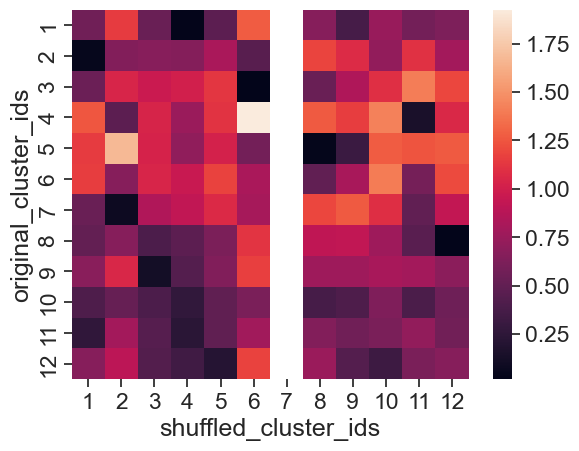

In [50]:
# SSE values for one iteration
n_boot = 0
sns.heatmap(SSE_matrix_dict[n_boot])

<AxesSubplot:ylabel='None-experience_level'>

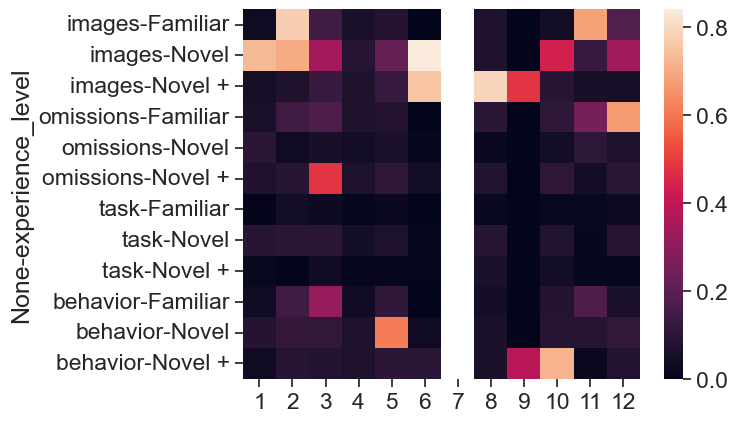

In [52]:
# shuffled clusters for one iteration 
sns.heatmap(nb_mean_dropout_scores_shuffled[n_boot])

<AxesSubplot:ylabel='None-experience_level'>

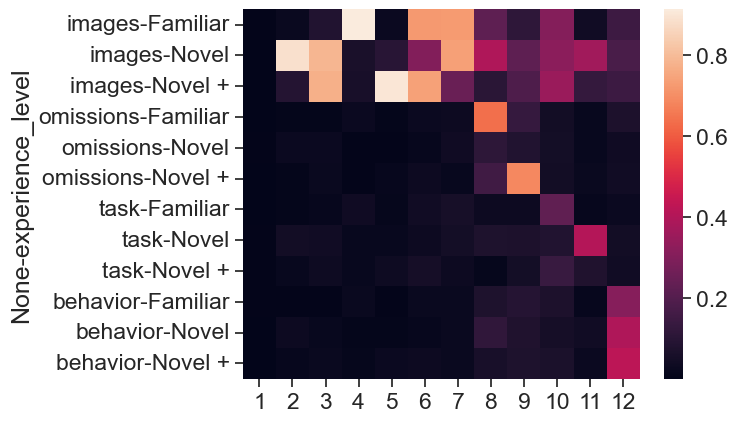

In [53]:
# original cluster coding scores
sns.heatmap(original_mean_dropout_scores)

mapping should be {2: 1, 3:6, 8:12, 9:3}

Text(41.25, 0.5, 'original cluster')

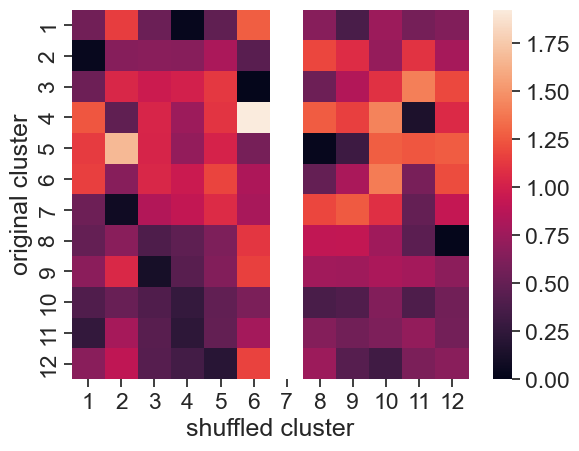

In [54]:
# plot SSE values again
fig, ax = plt.subplots()
ax = sns.heatmap(SSE_matrix_dict[n_boot], ax=ax, vmin=0)
ax.set_xticklabels(np.arange(1,13,1))
ax.set_xlabel('shuffled cluster')
ax.set_yticklabels(np.arange(1,13,1));
ax.set_ylabel('original cluster')

Text(41.25, 0.5, 'original cluster')

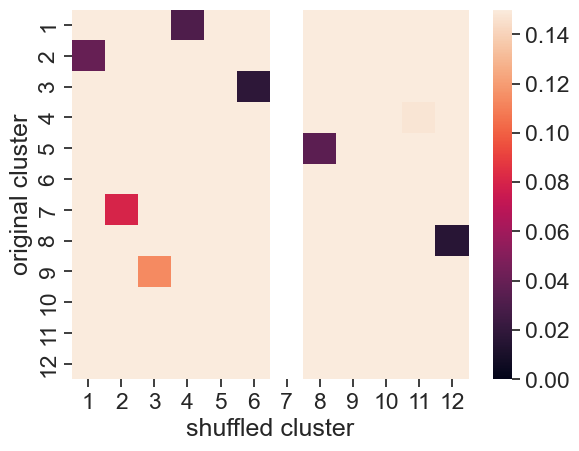

In [55]:
# only show SSE values that are less than the threshold for matching
fig, ax = plt.subplots()
ax = sns.heatmap(SSE_matrix_dict[n_boot], ax=ax, vmin=0, vmax=threshold)
ax.set_xticklabels(np.arange(1,13,1))
ax.set_xlabel('shuffled cluster')
ax.set_yticklabels(np.arange(1,13,1));
ax.set_ylabel('original cluster')

In [56]:
# check the mapping dictionary
SSE_mapping[n_boot]

{1: 4,
 2: 1,
 3: 6,
 4: 11,
 5: 8,
 6: -1,
 7: 2,
 8: 12,
 9: 3,
 10: -1,
 11: -1,
 12: -1}

mapping should be {2: 1, 3:6, 8:12, 9:3}

Looks good!! 

In [57]:
save_dir

'//allen/programs/braintv/workgroups/nc-ophys/visual_behavior/platform_paper_cache_new\\clustering'

In [85]:
folder

'shuffle_control'

In [58]:
# filename = os.path.join(save_dir,'old_files/sorted_SSE_matrix.h5')
filename = os.path.join(save_dir, folder, 'sorted_SSE_matrix.h5')

if os.path.exists(filename):
    SSE_matrix_sorted = pd.read_hdf(filename, key='df')
else:
    SSE_matrix_sorted = processing.sort_SSE_values(SSE_matrix_dict, SSE_mapping)

In [59]:
# this is the same as original_mean_dropout_scores, but with exp and regressor labels and transposed
original_cluster_means = plotting.get_cluster_means(original_feature_matrix, original_cluster_meta)
original_cluster_means

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\plotting.py:1547: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  cluster_means = feature_matrix.merge(cluster_meta[['cluster_id']], on='cell_specimen_id').groupby('cluster_id').mean()


images                     omissions                      \
            Familiar     Novel   Novel +  Familiar     Novel   Novel +   
cluster_id                                                               
1           0.008245  0.003125  0.003918  0.003412  0.006359  0.003516   
2           0.026374  0.885535  0.090434  0.009872  0.030257  0.012025   
3           0.080408  0.787501  0.772291  0.011749  0.030253  0.024485   
4           0.912700  0.063783  0.062232  0.027475  0.007509  0.007982   
5           0.027436  0.098206  0.899775  0.010326  0.008291  0.018363   
6           0.722273  0.302357  0.740893  0.028666  0.018656  0.032498   
7           0.725841  0.737746  0.250362  0.034035  0.038424  0.020644   
8           0.224085  0.394340  0.105247  0.637385  0.109848  0.155919   
9           0.115085  0.225764  0.190126  0.131063  0.081760  0.688202   
10          0.304873  0.321134  0.352912  0.047576  0.051155  0.044890   
11          0.044669  0.367929  0.129072  0.020546  0.022731  0.024079   
12          0.149195  0.177314  0.145936  0.071048  0.037982  0.043887   

                task                      behavior                      
            Familiar     Novel   Novel +  Familiar     Novel   Novel +  
cluster_id                                                              
1           0.002150  0.006699  0.007353  0.007489  0.002918  0.004299  
2           0.010832  0.045034  0.023359  0.009004  0.031560  0.018400  
3           0.016797  0.044318  0.036193  0.009143  0.020873  0.023867  
4           0.041011  0.021859  0.023019  0.023732  0.011571  0.014162  
5           0.013372  0.021541  0.037306  0.007914  0.009790  0.030107  
6           0.042247  0.032020  0.052703  0.024364  0.018608  0.031396  
7           0.055912  0.049027  0.033506  0.024960  0.025498  0.023931  
8           0.031294  0.076533  0.015242  0.075131  0.117091  0.059593  
9           0.032947  0.070935  0.050241  0.094494  0.077583  0.075618  
10          0.229685  0.082826  0.140430  0.071373  0.054951  0.069023  
11          0.017495  0.407519  0.079671  0.017601  0.043198  0.028428  
12          0.029086  0.048292  0.042771  0.308668  0.395623  0.422146

In [60]:
shuffled_clusters_dict = processing.get_matched_clusters_means_dict(SSE_mapping, nb_mean_dropout_scores_shuffled_unstacked, 
                                                                    metric='mean', shuffle_type=None, cre_line=None) 
        
shuffled_cluster_means = processing.get_shuffled_cluster_means(shuffled_clusters_dict, n_clusters)

In [61]:
# # returns a dataframe containing the SSE values for matched clusters for all n_boots, 
# # with columns representing the matched shuffled cluster, and the row representing the original cluster
# # the row values are the SSE values for matching of each matched cluster to all original clusters
# # (i.e. if cluster 5 was matched to cluster 1, what are the SSE values for cluster 5 across all the original clusters?)


# n_boots = SSE_mapping.keys()
# SSE_matrix_concatenated = pd.DataFrame()
# for n in n_boots:
#     new_SSE_matrix = pd.DataFrame(index=original_cluster_ids, columns=original_cluster_ids)
#     new_SSE_matrix.index.name = 'original_cluster_id'
#     original_cluster_ids = list(SSE_mapping[n].keys())
#     for i, original_cluster_id in enumerate(original_cluster_ids): 
#         # get matched cluster for this cluster and n_boot
#         matched_cluster_id = SSE_mapping[n][original_cluster_id]
#         # if there was a match, get the SSE values for mapping of matched cluster to original clusters
#         if matched_cluster_id != -1: 
#             matched_sse_values = SSE_matrix_dict[n][matched_cluster_id].values # these are organized by original cluster ID
#             # matched cluster ID is the index, original clusters are the columns
#             new_SSE_matrix.loc[original_cluster_id] = matched_sse_values
#         else: # otherwise set the row values for this cluster to zero
#             nan_array = np.zeros(len(original_cluster_ids))
#             nan_array[:] = np.nan
#             new_SSE_matrix.loc[original_cluster_id] = nan_array

#     new_SSE_matrix = new_SSE_matrix.reset_index()
#     new_SSE_matrix['n_boot'] = n
#     SSE_matrix_concatenated = pd.concat([SSE_matrix_concatenated, new_SSE_matrix])

# return SSE_matrix_concatenated


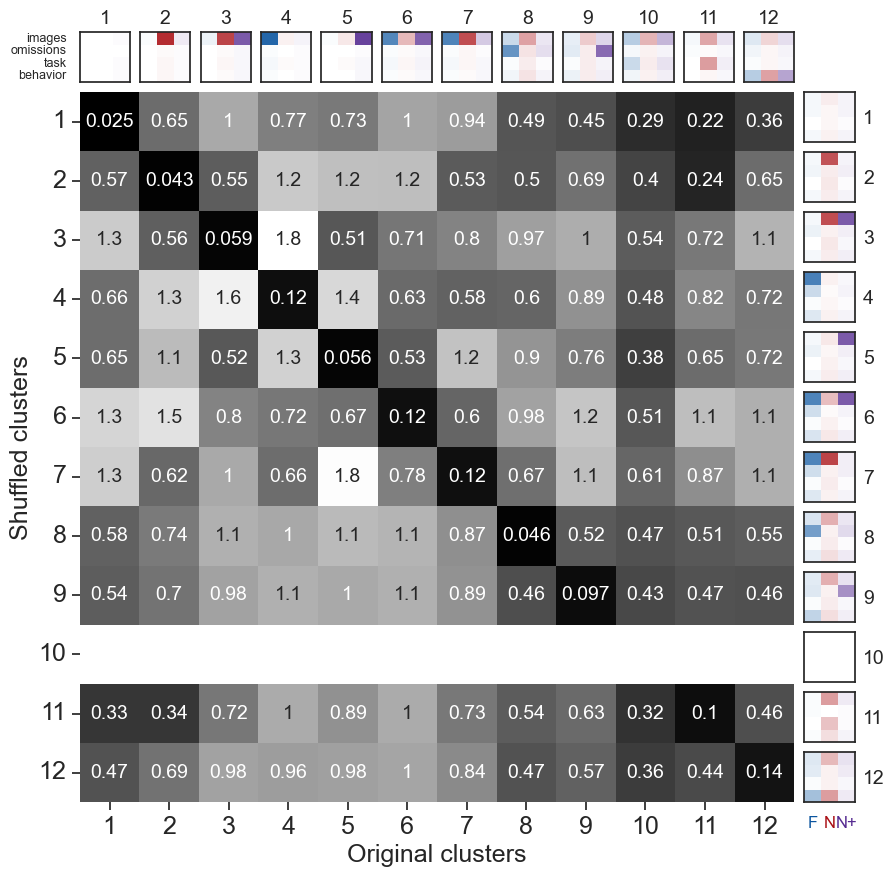

In [62]:
fig = plotting.plot_cluster_heatmaps_with_SSE_matrix(original_cluster_means, shuffled_cluster_means, SSE_matrix_sorted,
                                               session_colors=True, experience_index=None, save_dir=fig_path, folder=folder)

#### get colorbar for sse

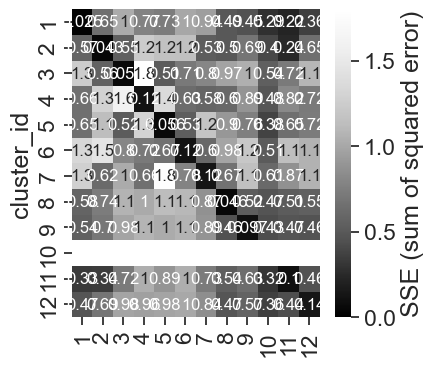

In [63]:
SSE_mean = SSE_matrix_sorted.drop(columns=['n_boot']).groupby('cluster_id').mean()
labels = np.arange(1, len(SSE_mean)+1)
fig, ax = plt.subplots(figsize=(4,4))
ax = sns.heatmap(SSE_mean, annot=True, cmap='Greys_r', annot_kws={"size": 12}, vmin=0, vmax=1.8, 
                yticklabels=labels, xticklabels=labels, cbar=True, ax=ax, cbar_kws={'label':'SSE (sum of squared error)'})

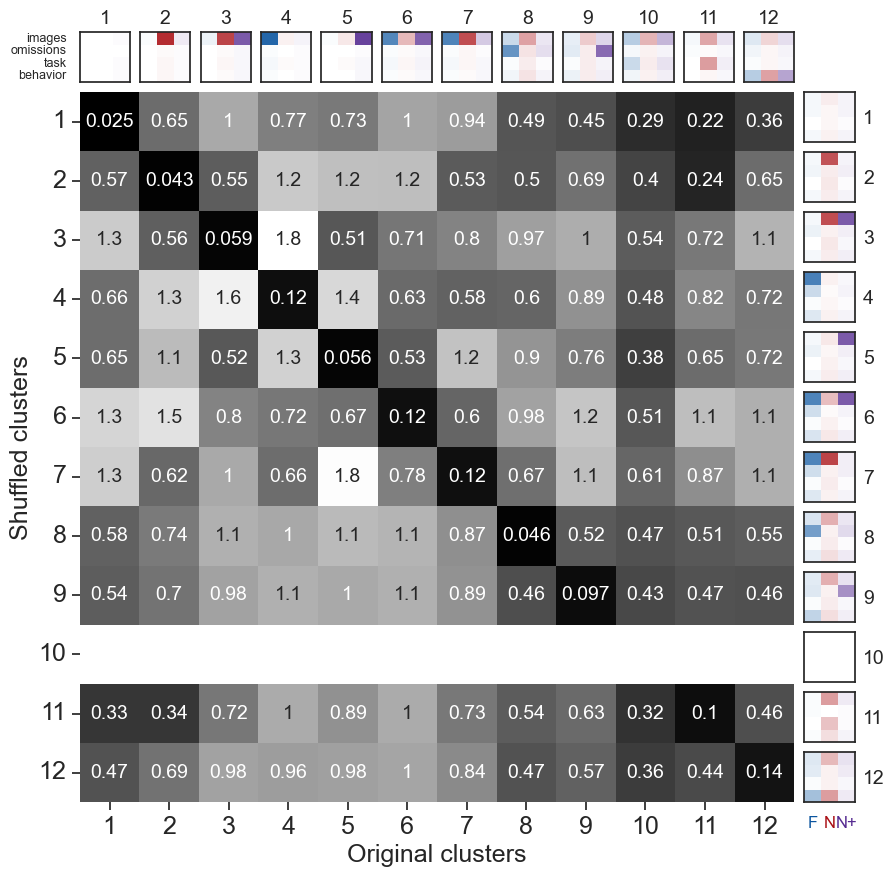

In [64]:
fig = plotting.plot_cluster_heatmaps_with_SSE_matrix(original_cluster_means, shuffled_cluster_means, SSE_matrix_sorted,
                                               session_colors=True, experience_index=None, save_dir=fig_path, folder=folder)

In [65]:
# somewhere task and beahvioral are switched and i cant find where
# df = shuffled_cluster_means.rename(columns={'task': 'temp', 'behavioral': 'task', 'temp': 'behavioral'})
# shuffled_cluster_means_patch_fix = df.rename(columns={'temp': 'behavioral'})

In [66]:
shuffled_clusters_dict = processing.get_matched_clusters_means_dict(SSE_mapping, nb_mean_dropout_scores_shuffled_unstacked, 
                                                                    metric='mean', shuffle_type=None, cre_line=None) 
        
shuffled_cluster_means = processing.get_shuffled_cluster_means(shuffled_clusters_dict, n_clusters)

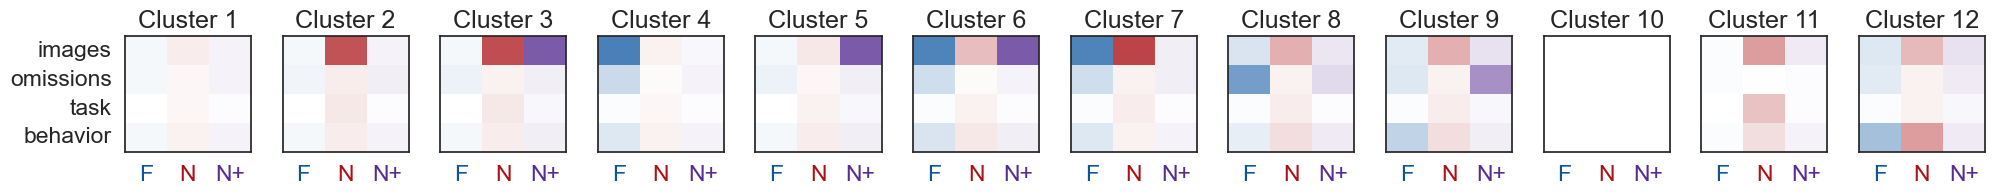

In [67]:
# folder = 'figure_4/suppl_20'
plotting.plot_matched_clusters_heatmap_remapped(shuffled_clusters_dict , abbreviate_features=False, abbreviate_experience=True, small_fontsize=False,
                                  session_colors=True, save_dir=fig_path, folder=folder)

In [68]:
### splitting by cre line needs work

In [69]:
# get mean dropout scores for matched clusters by cre line to plot mean matched dropout scores
SSE_mapping_dict = {}
shuffled_clusters_dict_cre = {}
shuffled_cluster_means_cre = {}
for cre_line in cre_lines:
    print(cre_line)
    SSE_mapping_dict[cre_line]=SSE_mapping
    shuffled_clusters_dict_cre[cre_line] = processing.get_matched_clusters_means_dict(SSE_mapping, cre_mean_dropout_scores_shuffled_unstacked[cre_line],
                                                                    metric='mean', shuffle_type=None, cre_line=None) 
        
# replace nans with 0 in SST cluster 12
shuffled_clusters_dict_cre[cre_lines[1]][12] = shuffled_clusters_dict_cre[cre_lines[1]][12].replace(np.nan, 0)

Slc17a7-IRES2-Cre
Sst-IRES-Cre
Vip-IRES-Cre


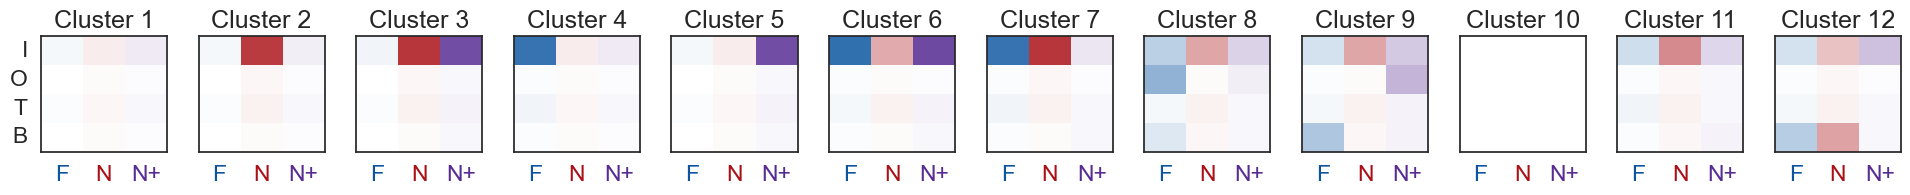

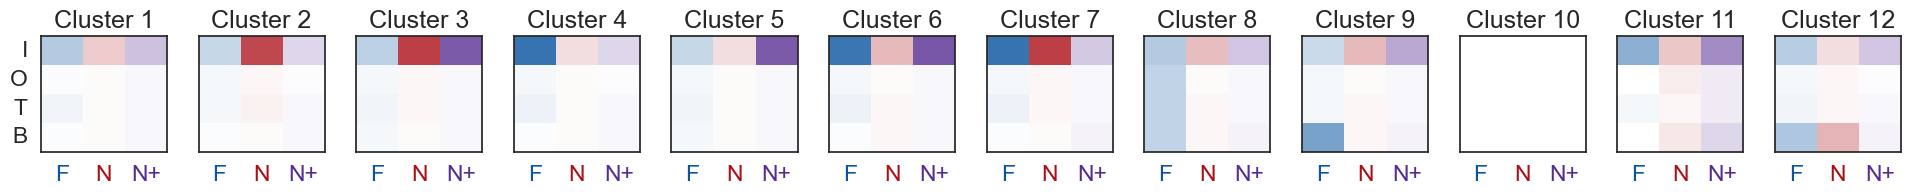

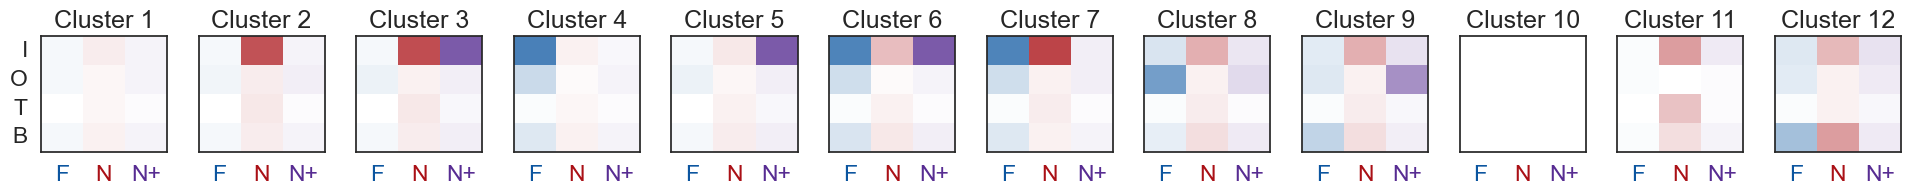

In [70]:
for cre_line in cre_lines:
    plotting.plot_matched_clusters_heatmap_remapped(shuffled_clusters_dict_cre[cre_line], abbreviate_features=True, abbreviate_experience=True, small_fontsize=False,
                                  session_colors=True, save_dir=None, folder=folder , figsize=(3*12, 1.7))

## panels e and f probability of clusters in shuffled data

This requires more thinking. Since the clusters were matched across all cells, SST and VIP cells shuffled clusters can match Exc original clusters, which makes computing sizes and probabilities across cre lines a bit consufing. 

In [71]:
## split shuffled dataframes by cre line
shuffled_labels_cre={}
for cre_line in cre_lines: 
    nb_labels_shuffled = {}
    for n_boot in n_boots:
        nb_labels_shuffled[n_boot] = shuffled_labels[n_boot][shuffled_labels[n_boot].cre_line==cre_line]
    shuffled_labels_cre[cre_line] = nb_labels_shuffled


In [72]:
# difference in size plotted here (x-y)/(x+y) when not normalized, may come from two different population 
# total of all used clusters. One small issue is that in original clusters we have dropped 20 cells due to being 
# too small of a cluster. In clustering of shuffled datasets we do not do that. Even if we clean shuffled labels
# the number of clusters excluded will likely also depend on each shuffle. So, N originals != N shuffled. Since populations are different, 
# there is a need to normalize. But that doesnt solve another discrepancy. The cells in clusters unmatched are disgarded.
# So the population of cells that ends up being matched is really different from original population. So when comparing the
# difference in cluster sizes, total of original clusters =3901, total of matched shuffled clsuters < 3901. 
# This will bias original clusters to be bigger than shuffled? 


# Anyway, to udress it we can normalize cluster sizes to total n in matched clusters. But I started to run into this error
# decided to abandon. Not sure if it makes sense.

# this may be an issue addressed by marina? in adjust_expected_N: 
# get_cluster_size_variance(SSE_mapping, cluster_meta_shuffled, normalize=False, use_nan=False, adjust_to_expected_N=False)

In [73]:
# Normalize cluster sizes since shuffled and original dataframes will contain different number of cells
normalize = True
shuffled_cluster_sizes_cre = {}
for cre_line in cre_lines:
     shuffled_cluster_sizes_cre[cre_line] = processing.get_cluster_size_variance(SSE_mapping, 
                                                                                 shuffled_labels_cre[cre_line], normalize=normalize)
                
original_cluster_sizes_cre = {}
for cre_line in cre_lines:
    cluster_meta_cre = original_cluster_meta[original_cluster_meta.cre_line == cre_line]
    original_cluster_sizes_cre[cre_line] = cluster_meta_cre.value_counts('cluster_id', normalize=normalize).reindex(range(1,n_clusters+1))
    original_cluster_sizes_cre[cre_line] = original_cluster_sizes_cre[cre_line].replace(np.nan, 0)

In [86]:
save_dir

'//allen/programs/braintv/workgroups/nc-ophys/visual_behavior/platform_paper_cache_new\\clustering'

In [74]:
filename = os.path.join(save_dir, 'difference_in_cluster_size_shuffle_control.h5')
if os.path.exists(filename):
    cluster_size_diff = pd.read_hdf(filename, key='df')
else:
    cluster_size_diff = processing.get_cluster_size_differece_df(original_cluster_sizes_cre, 
                                                             shuffled_cluster_sizes_cre, cre_line=cre_lines)
    cluster_size_diff.to_hdf(filename, key='df')

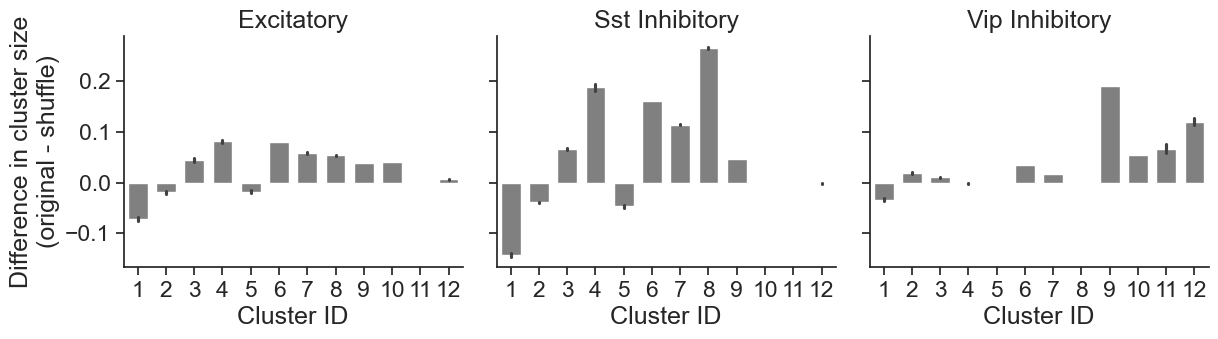

In [75]:
plotting.plot_cluster_size_difference_for_shuffle(cluster_size_diff, y = 'abs_cluster_size_diff', save_dir=fig_path, folder=folder)

In [76]:
# plotting.plot_cluster_size_difference_for_shuffle(cluster_size_diff, y ='cluster_size_diff', sharey=False,
#                                                   save_dir=fig_path, folder=folder)

In [77]:
cluster_size_diff[(cluster_size_diff.cre_line=='Slc17a7-IRES2-Cre') & (cluster_size_diff.cluster_id==1)]

,cre_line,cluster_id,n_boot,cluster_size_diff,abs_cluster_size_diff,og_cluster_size,shuffle_size
0,Slc17a7-IRES2-Cre,1,0,-0.146067,-0.074894,0.218921,0.293814
1,Slc17a7-IRES2-Cre,1,1,-0.160953,-0.083990,0.218921,0.302911
2,Slc17a7-IRES2-Cre,1,2,-0.159977,-0.083384,0.218921,0.302304
3,Slc17a7-IRES2-Cre,1,3,-0.149588,-0.077016,0.218921,0.295937
4,Slc17a7-IRES2-Cre,1,4,-0.161927,-0.084597,0.218921,0.303517
...,...,...,...,...,...,...,...
495,Slc17a7-IRES2-Cre,1,495,-0.180011,-0.096119,0.218921,0.315039
496,Slc17a7-IRES2-Cre,1,496,-0.161440,-0.084294,0.218921,0.303214
497,Slc17a7-IRES2-Cre,1,497,-0.164352,-0.086113,0.218921,0.305033
498,Slc17a7-IRES2-Cre,1,498,-0.145562,-0.074591,0.218921,0.293511


#### Probability

In [78]:
cluster_probabilities = processing.compute_probabilities(SSE_mapping, shuffled_labels)


In [79]:
probability_df = processing.get_cluster_probability_df(cluster_probabilities, cre_lines=None,
                               columns=['cluster_id', 'probability'])

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\processing.py:3677: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  shuffle_probability_df = shuffle_probability_df.append(cluster_meta, ignore_index=True)
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\processing.py:3677: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  shuffle_probability_df = shuffle_probability_df.append(cluster_meta, ignore_index=True)
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\processing.py:3677: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  shuffle_probability_df = shuffle

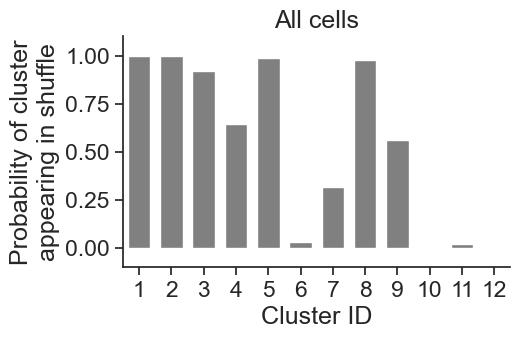

In [80]:
plotting.plot_cluster_probability_for_shuffle(probability_df, save_dir=fig_path, folder=folder)

### per cre

In [81]:
cluster_probabilities_cre = {}
for cre_line in cre_lines:
     cluster_probabilities_cre[cre_line] = processing.compute_probabilities(SSE_mapping, shuffled_labels_cre[cre_line])


In [82]:
probability_df = processing.get_cluster_probability_df(cluster_probabilities_cre, cre_lines=cre_lines,
                               columns=['cre_line', 'cluster_id', 'probability'])

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\processing.py:3677: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  shuffle_probability_df = shuffle_probability_df.append(cluster_meta, ignore_index=True)
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\processing.py:3677: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  shuffle_probability_df = shuffle_probability_df.append(cluster_meta, ignore_index=True)
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\processing.py:3677: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  shuffle_probability_df = shuffle

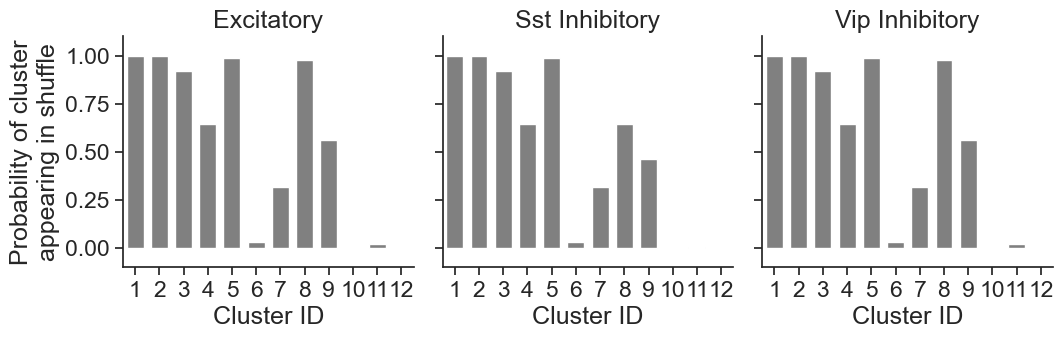

In [83]:
plotting.plot_cluster_probability_for_shuffle(probability_df, save_dir=fig_path, folder=folder, cre_lines=cre_lines)

In [84]:
# original Cell id shuffle only
# tmp_save_dir = r'\\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_plots\figure_4\all_cre_clustering_082823_n_14\240101_SSE_general'
# pkl_filename = 'Probability_for_Marina.pkl'
# probability_dict = pd.read_pickle(os.path.join(tmp_save_dir, pkl_filename))
# probability = pd.DataFrame(probability_dict[threshold])
# probability_clean = probability[probability.shuffle_type=='experience']
# plotting.plot_cluster_probability_for_shuffle(probability_clean, save_dir=fig_path, folder=folder)
